# Utilization Prediction

## a) Business Case

During the descriptives task, we defined three KPIs:

1) Utilization rate
2) Energy delivered per hour
3) Rate of registered user sessions

The business case behind these KPIs is defined as:

<br><br>
<center>
  <b style="font-size: 1.3em;">
    The prediction model enables the site operator to offer dynamic pricing to registered users to maximize revenue and energy throughput while smoothing demand.
  </b>
</center>
<br><br>

The model predicts the hourly utilization of a given site. This information can be used to offer dynamic pricing models: when utilization and energy delivered are low, prices can be lowered to encourage usage. Notifications can be sent to registered users, e.g. through an app, to increase engagement, improve site utilization and maximize energy throughput.


## b) Prediction Model

## Load Dataframes and inspect data

In [1]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import seaborn as sns
import holidays
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import os
os.environ["KERAS_BACKEND"] = "torch"
from keras import Sequential, Input # sequential model: https://keras.io/guides/sequential_model/
from keras.layers import Dense, Dropout


# Load prepared dataframes from pickle files
data_path = "../data_processed/"

with open(data_path + "df_prepared.pkl", "rb") as f:
    df = pickle.load(f)

with open(data_path + "merged_df_prepared.pkl", "rb") as f:
    merged_df = pickle.load(f)

with open(data_path + "relevant_weather_data_prepared.pkl", "rb") as f:
    relevant_weather_data = pickle.load(f)

print("DataFrames loaded successfully:")
print(f"  df shape: {df.shape}")
print(f"  merged_df shape: {merged_df.shape}")
print(f"  relevant_weather_data shape: {relevant_weather_data.shape}")

DataFrames loaded successfully:
  df shape: (65006, 21)
  merged_df shape: (65006, 27)
  relevant_weather_data shape: (26187, 9)


We choose site 1 for this task

In [2]:
print(merged_df.siteID.unique())
print(merged_df.stationID.dtype)
df_site_1 = merged_df[merged_df['siteID'] == '1']
df_site_1 = df_site_1.sort_values(by='connectionTime', ascending=True)

['1' '2']
object


In [3]:
mask = df['charging_duration'] == df['session_duration']
number = df[mask].shape[0]
print(f"Number of sessions where charging duration equals session duration: {number}")

Number of sessions where charging duration equals session duration: 8479


In [4]:
print(df_site_1['stationID'].nunique())

52


## Data Processing: Create hourly data of sessions

In [5]:
# function to create hourly features for site 1
def make_site1_hourly_features(df,
                               conn_col='connectionTime',
                               disc_col='disconnectTime',
                               station_col='stationID'):
    df = df.copy()
    df[conn_col] = pd.to_datetime(df[conn_col], errors='coerce')
    df[disc_col] = pd.to_datetime(df[disc_col], errors='coerce')

    n_stations = df[station_col].nunique()

    # function to calculate hourly contributions for each charging session
    def row_hour_contrib(row):
        start = row[conn_col]
        end = row[disc_col]
        if pd.isna(start) or pd.isna(end) or end <= start:
            return []

        hours = pd.date_range(
            start=start.floor('h'),
            end=(end - pd.Timedelta(seconds=1)).floor('h'),
            freq='h'
        )

        out = []
        for h in hours:
            h_start = max(start, h)
            h_end = min(end, h + pd.Timedelta(hours=1))
            minutes = (h_end - h_start).total_seconds() / 60.0
            if minutes > 0:
                # append hourly contribution
                out.append({
                    'datetime': h,
                    'minutes': minutes,

                })
        return out

    contrib = df.apply(row_hour_contrib, axis=1)
    tmp = pd.DataFrame([item for lst in contrib for item in lst])

    if tmp.empty:
        return pd.DataFrame(columns=[
            'datetime', 'hourly_utilization_minutes', 'hourly_utilization'
        ])

    # Hourly aggregation for utilization + additional features
    hourly = (
        tmp.groupby('datetime')
            .agg(
                hourly_utilization_minutes=('minutes', 'sum'),
            )
    )
    # calculate hourly utilization as a fraction of total available minutes
    hourly['hourly_utilization'] = (
        hourly['hourly_utilization_minutes'] / (n_stations * 60.0)
    ).clip(0, 1)
    hourly = hourly.reset_index('datetime')
    return hourly

    

In [6]:
df_site_1_features = make_site1_hourly_features(df_site_1, 'connectionTime', 'disconnectTime')
df_site_1_features.drop(columns=['hourly_utilization_minutes'], inplace=True)
df_site_1_features.head()

,datetime,hourly_utilization
0,2018-09-05 04:00:00-07:00,0.034498
1,2018-09-05 05:00:00-07:00,0.049119
2,2018-09-05 06:00:00-07:00,0.150577
3,2018-09-05 07:00:00-07:00,0.280224
4,2018-09-05 08:00:00-07:00,0.288462


In [7]:
df_site_1_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16123 entries, 0 to 16122
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype                              
---  ------              --------------  -----                              
 0   datetime            16123 non-null  datetime64[ns, America/Los_Angeles]
 1   hourly_utilization  16123 non-null  float64                            
dtypes: datetime64[ns, America/Los_Angeles](1), float64(1)
memory usage: 252.0 KB


## Feature Engineering

### Add before covid boolean

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Identify the Gap
# We calculate the time difference between each row
time_diffs = df_site_1_features['datetime'].diff()

# The largest gap will be our COVID period
gap_idx = time_diffs.idxmax()
gap_end = df_site_1_features.loc[gap_idx, 'datetime']
gap_start = df_site_1_features.loc[gap_idx - 1, 'datetime']

print(f"Gap detected between: {gap_start} and {gap_end}")
print(f"Total gap duration: {gap_end - gap_start}")

# 2. Add 'before_covid' column
# 1 if before the gap start, 0 if after (or at) the gap end
df_site_1_features['before_covid'] = (df_site_1_features['datetime'] <= gap_start).astype(int)

# Verify the split
print("\nValue counts for 'before_covid':")
print(df_site_1_features['before_covid'].value_counts())

Gap detected between: 2020-08-03 21:00:00-07:00 and 2020-11-18 12:00:00-08:00
Total gap duration: 106 days 16:00:00

Value counts for 'before_covid':
before_covid
1    11339
0     4784
Name: count, dtype: int64


DatetimeIndex(['2018-09-05 04:00:00-07:00', '2018-09-05 05:00:00-07:00',
               '2018-09-05 06:00:00-07:00', '2018-09-05 07:00:00-07:00',
               '2018-09-05 08:00:00-07:00', '2018-09-05 09:00:00-07:00',
               '2018-09-05 10:00:00-07:00', '2018-09-05 11:00:00-07:00',
               '2018-09-05 12:00:00-07:00', '2018-09-05 13:00:00-07:00',
               ...
               '2021-09-13 22:00:00-07:00', '2021-09-13 23:00:00-07:00',
               '2021-09-14 00:00:00-07:00', '2021-09-14 01:00:00-07:00',
               '2021-09-14 02:00:00-07:00', '2021-09-14 03:00:00-07:00',
               '2021-09-14 04:00:00-07:00', '2021-09-14 05:00:00-07:00',
               '2021-09-14 06:00:00-07:00', '2021-09-14 07:00:00-07:00'],
              dtype='datetime64[ns, America/Los_Angeles]', length=26524, freq='h')


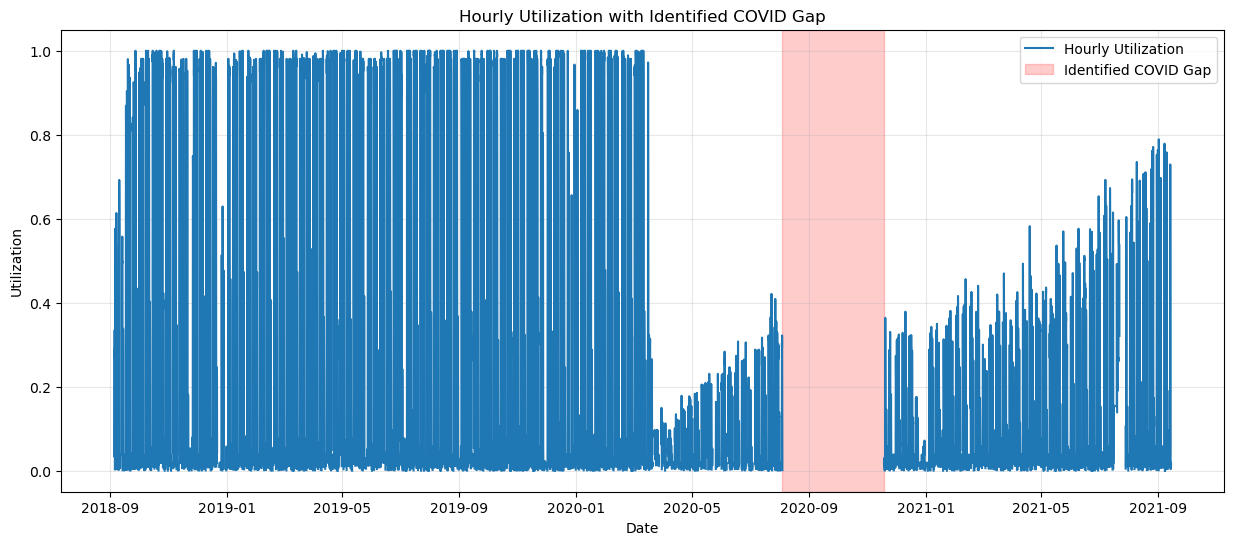

In [11]:
# Create a continuous hourly range from the very start to the very end
full_range = pd.date_range(start=df_site_1_features['datetime'].min(), 
                           end=df_site_1_features['datetime'].max(), 
                           freq='h')
print(full_range)
# Set datetime as index and reindex to show where the gaps are (will fill missing hours with NaN)
df_reindexed = df_site_1_features.set_index('datetime').reindex(full_range)

# Plotting
plt.figure(figsize=(15, 6))
plt.plot(df_reindexed.index, df_reindexed['hourly_utilization'], label='Hourly Utilization', color='tab:blue')

# Highlight the gap
plt.axvspan(gap_start, gap_end, color='red', alpha=0.2, label='Identified COVID Gap')

plt.title('Hourly Utilization with Identified COVID Gap')
plt.xlabel('Date')
plt.ylabel('Utilization')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# 1. Calculate the time difference between consecutive rows
# this helps find the largest gap in the Datetime Index
time_diffs = df_site_1_features.index.to_series().diff()

# 2. Identify the timestamp where the data resumes after the gap
gap_end_timestamp = time_diffs.idxmax()

print(f"Data resumes after gap at: {gap_end_timestamp}")

# 3. Create the 'before_covid' column
# It assigns 1 to all timestamps before the gap, and 0 to all those after
df_site_1_features['before_covid'] = (df_site_1_features.index < gap_end_timestamp).astype(int)
print(df_site_1_features['before_covid'].value_counts())

Data resumes after gap at: 1
before_covid
0    16122
1        1
Name: count, dtype: int64


### Add holiday, month, day of week, hour of day features

We add a feature for holidays as this  influence the utilization due to the fact that employees do not work at this and university is also closed there. Additionally we add the already know time features from the session dataset.

In [ ]:
US_holidays = holidays.US(state='CA')

# Ensure index is datetime
df_site_1_features.index = pd.to_datetime(df_site_1_features.index)

df_site_1_features['is_holiday'] = df_site_1_features.index.to_series().apply(lambda dt: dt in US_holidays)
df_site_1_features['holiday_flag'] = df_site_1_features['is_holiday'].astype(int)
df_site_1_features['holiday_name'] = df_site_1_features.index.to_series().apply(lambda dt: US_holidays.get(dt) if dt in US_holidays else '')

#Add time features based on the index
df_site_1_features['year'] = df_site_1_features.index.year
df_site_1_features['month'] = df_site_1_features.index.month
df_site_1_features['day'] = df_site_1_features.index.day
df_site_1_features['hour'] = df_site_1_features.index.hour
df_site_1_features['dayofweek'] = df_site_1_features.index.dayofweek
df_site_1_features['is_weekend'] = df_site_1_features['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'
    
df_site_1_features['season'] = df_site_1_features['month'].apply(get_season)

In [ ]:
df_site_1_features['util_last_hour_flag'] = df_site_1_features['hourly_utilization'].shift(1)

df_site_1_features['util_prev_day_flag'] = df_site_1_features['hourly_utilization'].shift(24)

df_site_1_features.head()

,datetime,hourly_utilization,before_covid,is_holiday,holiday_flag,holiday_name,year,month,day,hour,dayofweek,is_weekend,season,util_last_hour_flag,util_prev_day_flag
1970-01-01 00:00:00.000000000,2018-09-05 04:00:00-07:00,0.034498,1,True,1,New Year's Day,1970,1,1,0,3,0,Winter,NaN,NaN
1970-01-01 00:00:00.000000001,2018-09-05 05:00:00-07:00,0.049119,0,True,1,New Year's Day,1970,1,1,0,3,0,Winter,0.034498,NaN
1970-01-01 00:00:00.000000002,2018-09-05 06:00:00-07:00,0.150577,0,True,1,New Year's Day,1970,1,1,0,3,0,Winter,0.049119,NaN
1970-01-01 00:00:00.000000003,2018-09-05 07:00:00-07:00,0.280224,0,True,1,New Year's Day,1970,1,1,0,3,0,Winter,0.150577,NaN
1970-01-01 00:00:00.000000004,2018-09-05 08:00:00-07:00,0.288462,0,True,1,New Year's Day,1970,1,1,0,3,0,Winter,0.280224,NaN


In [ ]:
lag_cols = ['util_last_hour_flag', 'util_prev_day_flag']
df_site_1_features = df_site_1_features.dropna(subset=lag_cols)
df_site_1_features.head()

,datetime,hourly_utilization,before_covid,is_holiday,holiday_flag,holiday_name,year,month,day,hour,dayofweek,is_weekend,season,util_last_hour_flag,util_prev_day_flag
1970-01-01 00:00:00.000000024,2018-09-06 12:00:00-07:00,0.516774,0,True,1,New Year's Day,1970,1,1,0,3,0,Winter,0.558718,0.034498
1970-01-01 00:00:00.000000025,2018-09-06 13:00:00-07:00,0.503584,0,True,1,New Year's Day,1970,1,1,0,3,0,Winter,0.516774,0.049119
1970-01-01 00:00:00.000000026,2018-09-06 14:00:00-07:00,0.493750,0,True,1,New Year's Day,1970,1,1,0,3,0,Winter,0.503584,0.150577
1970-01-01 00:00:00.000000027,2018-09-06 15:00:00-07:00,0.453104,0,True,1,New Year's Day,1970,1,1,0,3,0,Winter,0.493750,0.280224
1970-01-01 00:00:00.000000028,2018-09-06 16:00:00-07:00,0.426213,0,True,1,New Year's Day,1970,1,1,0,3,0,Winter,0.453104,0.288462


### Create cyclic Features



In [ ]:
def create_cyclic_features(df):
    df = df.copy()

    # Hour of day
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    
    # Day of week
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    
    # Month of year
    df['month_sin'] = np.sin(2 * np.pi * (df['month'] - 1) / 12)
    df['month_cos'] = np.cos(2 * np.pi * (df['month'] - 1) / 12)

    # Year
    df['year_sin'] = np.sin(2 * np.pi * (df['year'] - df['year'].min()) / (df['year'].max() - df['year'].min() + 1))
    df['year_cos'] = np.cos(2 * np.pi * (df['year'] - df['year'].min()) / (df['year'].max() - df['year'].min() + 1))
    
    # Delete original features
    df = df.drop(columns=['hour', 'dayofweek', 'month', 'year'])
    
    return df


In [ ]:
df_site_1_features = create_cyclic_features(df_site_1_features)
df_site_1_features.head()

,datetime,hourly_utilization,before_covid,is_holiday,holiday_flag,holiday_name,day,is_weekend,season,util_last_hour_flag,util_prev_day_flag,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,month_sin,month_cos,year_sin,year_cos
1970-01-01 00:00:00.000000024,2018-09-06 12:00:00-07:00,0.516774,0,True,1,New Year's Day,1,0,Winter,0.558718,0.034498,0.0,1.0,0.433884,-0.900969,0.0,1.0,0.0,1.0
1970-01-01 00:00:00.000000025,2018-09-06 13:00:00-07:00,0.503584,0,True,1,New Year's Day,1,0,Winter,0.516774,0.049119,0.0,1.0,0.433884,-0.900969,0.0,1.0,0.0,1.0
1970-01-01 00:00:00.000000026,2018-09-06 14:00:00-07:00,0.493750,0,True,1,New Year's Day,1,0,Winter,0.503584,0.150577,0.0,1.0,0.433884,-0.900969,0.0,1.0,0.0,1.0
1970-01-01 00:00:00.000000027,2018-09-06 15:00:00-07:00,0.453104,0,True,1,New Year's Day,1,0,Winter,0.493750,0.280224,0.0,1.0,0.433884,-0.900969,0.0,1.0,0.0,1.0
1970-01-01 00:00:00.000000028,2018-09-06 16:00:00-07:00,0.426213,0,True,1,New Year's Day,1,0,Winter,0.453104,0.288462,0.0,1.0,0.433884,-0.900969,0.0,1.0,0.0,1.0


In [ ]:
df_site_1_features.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 16099 entries, 1970-01-01 00:00:00.000000024 to 1970-01-01 00:00:00.000016122
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype                              
---  ------               --------------  -----                              
 0   datetime             16099 non-null  datetime64[ns, America/Los_Angeles]
 1   hourly_utilization   16099 non-null  float64                            
 2   before_covid         16099 non-null  int64                              
 3   is_holiday           16099 non-null  bool                               
 4   holiday_flag         16099 non-null  int64                              
 5   holiday_name         16099 non-null  object                             
 6   day                  16099 non-null  int32                              
 7   is_weekend           16099 non-null  int64                              
 8   season               16099 non-null  object        

## Feature Selection

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = df_site_1_features.copy()
df_plot['day_name'] = df_plot.index.day_name()
df_plot['hour'] = df_plot.index.hour
df_plot['month_name'] = df_plot.index.month_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

### Averga Utilization by day of Week

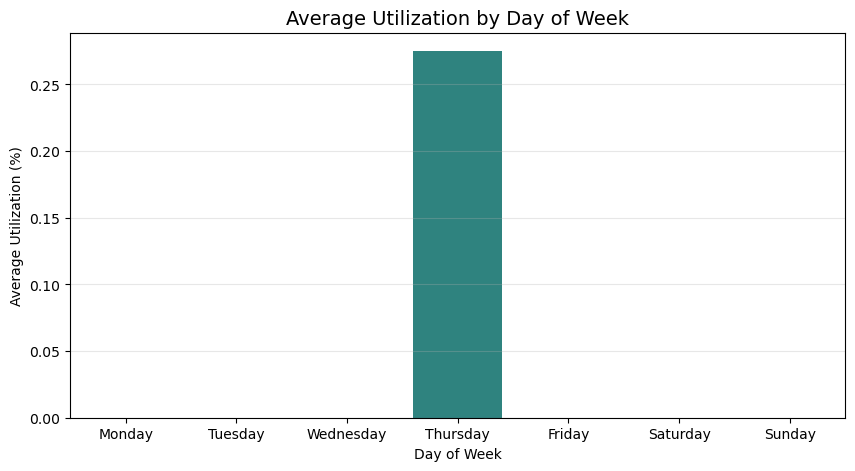

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_plot, 
    x='day_name', 
    y='hourly_utilization', 
    order=day_order, 
    palette='viridis', 
    hue='day_name',
    legend=False,
    errorbar=None
)
plt.title('Average Utilization by Day of Week', fontsize=14)
plt.ylabel('Average Utilization (%)')
plt.xlabel('Day of Week')
plt.grid(axis='y', alpha=0.3)
plt.show()

The data shows big contrast between high week utilization and near zero weekend usage. Therefore, we asssume day of the week to be a useful predictor of utilization.

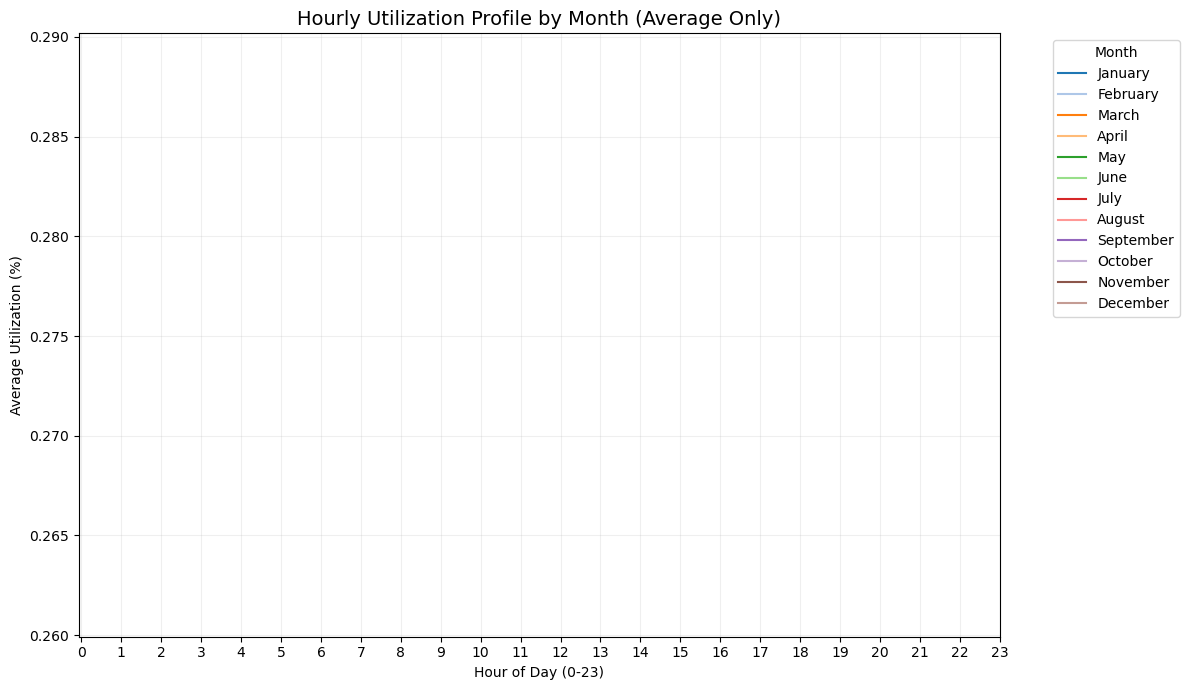

In [ ]:
plt.figure(figsize=(12, 7))

sns.lineplot(data=df_plot, x='hour', y='hourly_utilization', 
             hue='month_name', hue_order=month_order, 
             palette='tab20', errorbar=None)

plt.title('Hourly Utilization Profile by Month (Average Only)', fontsize=14)
plt.ylabel('Average Utilization (%)')
plt.xlabel('Hour of Day (0-23)')
plt.xticks(range(0, 24))
plt.legend(title='Month', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

As shown in the Figure above, the average utilization varies significantly at different times of the day. This temporal variation highlights the importance of including a hour of the day feature in the model, enabling the model to learn patterns based on the time of the day. Similarly, the data displays seasonal fluctuations and across different months. This monthly variation necessitates the inclusion of a month feature to allow the model to capture recurring seasonal patterns.

In [ ]:
# Visualize average utilization: Holidays vs. Non-Holidays
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_site_1_features, 
    x='hour', 
    y='hourly_utilization', 
    hue='is_holiday', 
    marker='o',
    errorbar=None  # Shows the mean only;
)

plt.title('Average Hourly Utilization: Holidays vs. Non-Holidays', fontsize=14)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Average Utilization (%)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)

# Update legend for clarity
plt.legend(title='Is Holiday', labels=['False (Working Day)', 'True (Holiday)'])
plt.show()

ValueError: Could not interpret value `hour` for `x`. An entry with this name does not appear in `data`.

<Figure size 1200x600 with 0 Axes>

As illustrated in the figure above, the average utilization on public holidays is much lower compared to working days.  This necessitates the inclusion of an is_holiday feature, allowing the model to differentiate between these two modes of behavior and avoid over estimating demand during public holidays.

In [ ]:
df_site_1_features.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 16099 entries, 2018-09-06 12:00:00-07:00 to 2021-09-14 07:00:00-07:00
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   hourly_utilization   16099 non-null  float64
 1   before_covid         16099 non-null  int64  
 2   is_holiday           16099 non-null  bool   
 3   holiday_flag         16099 non-null  int64  
 4   holiday_name         16099 non-null  object 
 5   day                  16099 non-null  int32  
 6   is_weekend           16099 non-null  int64  
 7   season               16099 non-null  object 
 8   util_last_hour_flag  16098 non-null  float64
 9   util_prev_day_flag   16075 non-null  float64
 10  hour_sin             16099 non-null  float64
 11  hour_cos             16099 non-null  float64
 12  dayofweek_sin        16099 non-null  float64
 13  dayofweek_cos        16099 non-null  float64
 14  month_sin            16099 non-null  fl

Train Test Split 

In [ ]:
df_site_1_features.sort_index()
features = [
    col for col in df_site_1_features.columns 
    if col != 'hourly_utilization'
]
print (features)

['before_covid', 'is_holiday', 'holiday_flag', 'holiday_name', 'day', 'is_weekend', 'season', 'util_last_hour_flag', 'util_prev_day_flag', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'month_sin', 'month_cos', 'year_sin', 'year_cos']


## Training Test Validation Split on selected features

In [ ]:
X = df_site_1_features[['hour', 'dayofweek', 'month', 'before_covid']]#, 'util_last_hour_flag', 'util_prev_day_flag']]
y = df_site_1_features['hourly_utilization']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)
x_train, x_hold, y_train, y_hold = train_test_split(x_train, y_train, test_size=(0.2/0.7), random_state=1)

print(len(x_train), len(x_hold), len(x_test))

8061 3225 4837


## Modeling

### Regression Code

We run different models of polynomial regression with ridge and lasso regularization to predict charging session duration. Our approach includes:

1. **Polynomial Features**: We test polynomial degrees from 1 to 7 to capture non-linear relationships the features from the session data set

2. **Model Types**:
   - **Linear Regression**: Baseline model without regularization
   - **Ridge Regression**: L2 regularization to penalize large coefficients and reduce overfitting
   - **Lasso Regression**: L1 regularization to perform feature selection while reducing overfitting

3. **Regularization Strength**: For Ridge and Lasso, we test alpha values [0.01, 0.1, 1, 10] to find optimal regularization strength. Higher alpha values increase the penalty.

4. **Cross-validation Approach**: We train on the training set and evaluate on the holdout set using the R² metric to prevent overfitting and select the best model.

The goal is to find the model that best generalizes to unseen data by balancing model complexity with prediction accuracy, as measured by the R² score which indicates the proportion of variance explained by the model.

In [ ]:
degrees = range(1, 8) #TODO später wieder höher stellen, dauert sonst zu lange in der ausführung
alphas = [0.01, 0.1, 1, 10]
models = ["linear", "Ridge", "Lasso"]
results = []

In [ ]:
def run_models(models, degrees, alphas, 
               x_train, x_hold, y_train, y_hold):
    rows = []  # list of dicts, reusable each call

    for model in models:
        for degree in degrees:
            # create polynomial features
            poly = PolynomialFeatures(degree=degree, include_bias=False)
            X_train_poly = poly.fit_transform(x_train)
            X_hold_poly = poly.transform(x_hold)

            # standardize
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train_poly)
            X_hold_scaled = scaler.transform(X_hold_poly)

            if model in ["Ridge", "Lasso"]:
                for alpha in alphas:
                    if model == "Ridge":
                        reg = Ridge(alpha=alpha)
                    else:
                        reg = Lasso(alpha=alpha, max_iter=10000)

                    reg.fit(X_train_scaled, y_train)

                    y_hold_pred = reg.predict(X_hold_scaled)
                    mse_val = mean_squared_error(y_hold, y_hold_pred)
                    r2_val = r2_score(y_hold, y_hold_pred)

                    rows.append({
                        "model": model,
                        "degree": degree,
                        "alpha": alpha,
                        "mse": mse_val,
                        "r2": r2_val,
                        "poly": poly,
                        "scaler": scaler,
                        "reg": reg
                    })
            else:
                reg = LinearRegression()
                reg.fit(X_train_scaled, y_train)
                y_hold_pred = reg.predict(X_hold_scaled)
                mse_val = mean_squared_error(y_hold, y_hold_pred)

                rows.append({
                    "model": model,
                    "degree": degree,
                    "alpha": None,
                    "mse": mse_val,
                    "poly": poly,
                    "scaler": scaler,
                    "reg": reg
                })

    return pd.DataFrame(rows)


In [ ]:
# get the model with the highest R2 on holdout set
results = run_models(models, degrees, alphas, x_train, x_hold, y_train, y_hold)
best_idx = results["r2"].idxmax()
best_model = results.loc[best_idx]

print(best_model)

model                                                Ridge
degree                                                   7
alpha                                                 0.01
mse                                               0.034968
poly      PolynomialFeatures(degree=7, include_bias=False)
scaler                                    StandardScaler()
reg                                      Ridge(alpha=0.01)
r2                                                0.710697
Name: 31, dtype: object


We see that the best model uses **Ridge regularization**, has a **polynomial degree of 7** with an alpha of **0.01**. This configuration indicates that:

- **Ridge Regression** was more effective than Lasso, suggesting that all features contribute meaningfully to predicting charging duration rather than needing feature selection.
- **Polynomial degree 7** captures complex non-linear relationships between the features of the session dataset, suggesting that the interaction between multiple session factors is important.
- **Low alpha (0.01)** means minimal regularization penalty was needed, indicating the model doesn't suffer from severe overfitting with the polynomial features.

The model's performance on the holdout set yields an **R² score of 0.71**, meaning it explains 71% of the variance in utilzation of the charging hubs. This is a solid result indicating good predictive power while leaving some variance unexplained, which could be attributed to factors not captured in the session data alone(e.g. weather, ...)

In [ ]:
best_poly = best_model['poly']
best_scaler = best_model['scaler']
best_reg = best_model['reg']

X_test_poly = best_poly.transform(x_test)
X_test_scaled = best_scaler.transform(X_test_poly)

y_test_pred = best_reg.predict(X_test_scaled)

# calculate test metrics
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"Test MSE: {mse_test}")
print(f"Test R2: {r2_test}")


Test MSE: 0.036492192244002006
Test R2: 0.6940802812663008


On the test set, we achieve an **R² score of 0.69**, which is slightly lower than the holdout set performance (0.71). This modest decrease is expected and indicates good generalization—the model doesn't show signs of significant overfitting. The test R² of 0.69 means the model explains 69% of the variance in charging hub utilization on completely unseen data. The 2-point difference between holdout and test performance suggests the model is stable and reliable for making predictions on new data.

### Decision Tree Code

Decision trees offer a different approach to regression that captures complex non-linear relationships without requiring feature scaling or polynomial transformations. Unlike linear models, decision trees recursively partition the feature space based on feature values that minimize prediction error at each split, creating a hierarchical structure that is interpretable and can reveal feature interactions.

However, decision trees are prone to overfitting. Which leads to the problem that they memorize training data rather than learning generalizable patterns. To address this, we employ **cost complexity pruning**, which removes branches that provide minimal improvement to the overall model performance. Combined with **GridSearchCV**, we systematically search over pruning parameters to find the optimal tree complexity that balances bias and variance, ultimately selecting the model that performs best on validation data. This systematic hyperparameter tuning ensures we capture the tree's predictive power while preventing overfitting to training-specific noise.

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

# 1. Initialize a basic tree
regr = DecisionTreeRegressor(random_state=42)

# 2. Get the pruning path
path = regr.cost_complexity_pruning_path(x_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [ ]:
# 3. Use these alphas in Grid Search
from sklearn.model_selection import GridSearchCV

param_grid = {
    'ccp_alpha': ccp_alphas[::5], # Subsample alphas to speed up search
    'min_samples_leaf': [5, 10, 20]
}

grid_search = GridSearchCV(DecisionTreeRegressor(), param_grid, cv=5)
grid_search.fit(x_train, y_train)

,estimator,DecisionTreeRegressor()
,param_grid,"{'ccp_alpha': array([0.0000...90920551e-03]), 'min_samples_leaf': [5, 10, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


<Axes: title={'center': 'Feature Importance'}>

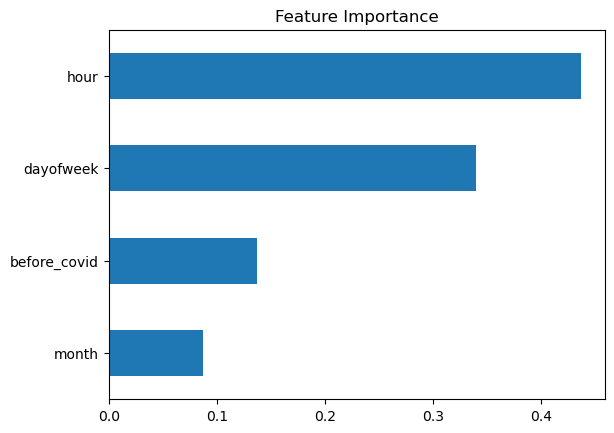

In [ ]:
importances = pd.Series(grid_search.best_estimator_.feature_importances_, index=x_train.columns)
importances.sort_values().plot(kind='barh', title='Feature Importance')

The feature importance plot reveals which variables the decision tree relied on most when making predictions.
**Hour** is the dominant predictor with an importance score of ~0.43, followed by **dayofweek** (~0.32). **before_covid** (~0.13) and **month** (~0.08) contribute less significantly. These results indicate that temporal patterns—specifically the time of day and day of the week—are the strongest drivers of charging hub utilization, while seasonal and historical factors play supporting roles.

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# 1. Use the best estimator from your GridSearch to make predictions
y_pred = grid_search.best_estimator_.predict(x_test)

# 2. Calculate standard regression metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # Root Mean Squared Error
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Model Performance on Test Set ---")
print(f"R-squared: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}%")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}%")

--- Model Performance on Test Set ---
R-squared: 0.7167
Mean Absolute Error (MAE): 0.11%
Root Mean Squared Error (RMSE): 0.18%


The decision tree model achieved strong performance on the test set with an **R² of 0.7167**, meaning it explains approximately 72% of the variance in charging hub utilization. The **MAE of 0.11%** and **RMSE of 0.18%** indicate low average prediction errors, demonstrating the model's effectiveness at capturing charging patterns and generalizing well to unseen data.

Best Hyperparameters: {'ccp_alpha': np.float64(9.251313927791907e-05), 'min_samples_leaf': 5}
Tree Depth: 11
Number of Leaves: 35


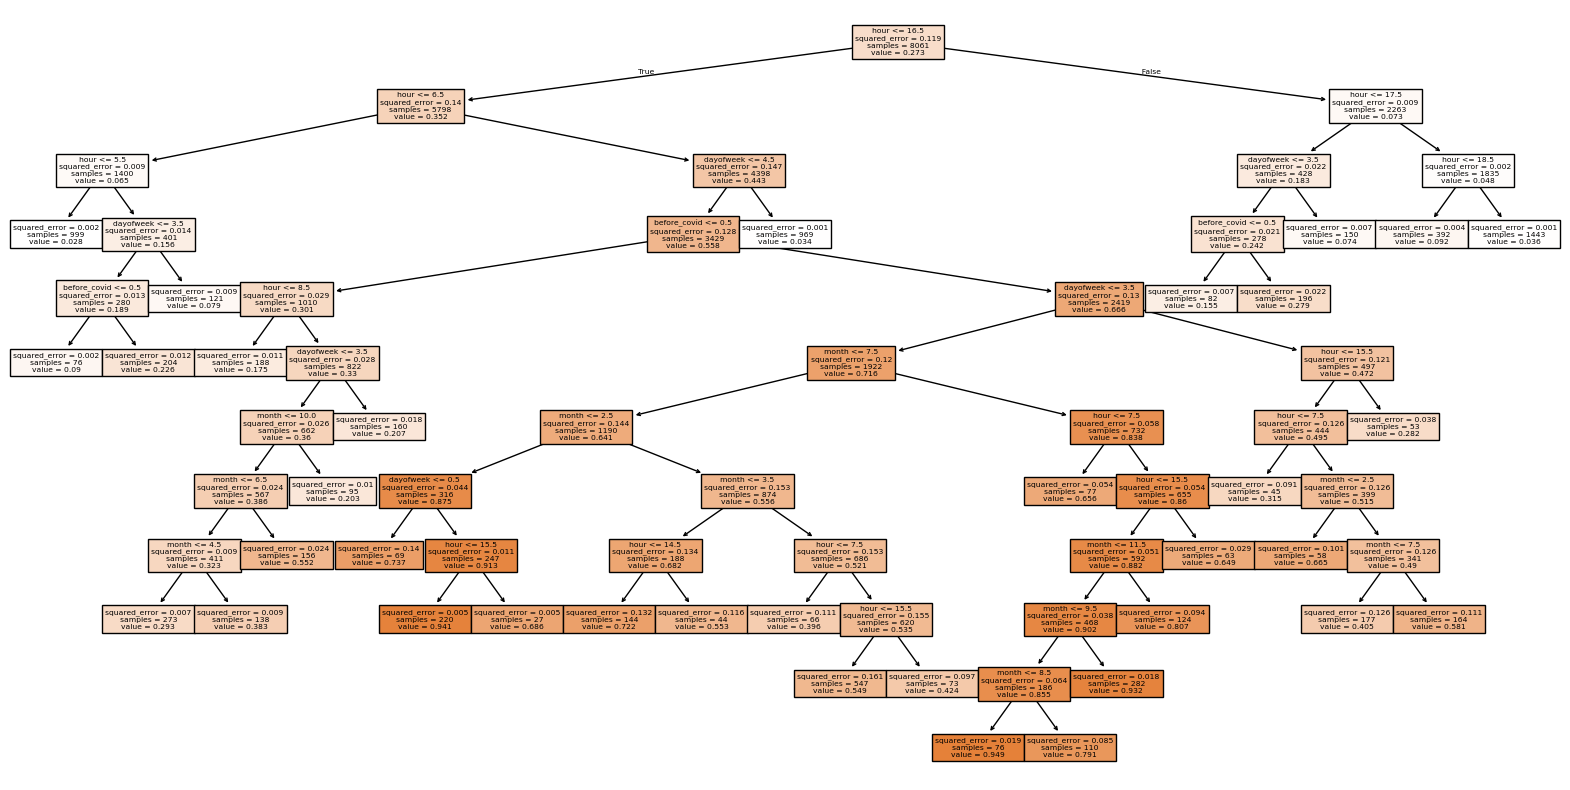

In [ ]:

print("Best Hyperparameters:", grid_search.best_params_)
print(f"Tree Depth: {grid_search.best_estimator_.get_depth()}")
print(f"Number of Leaves: {grid_search.best_estimator_.get_n_leaves()}")

# Plot the actual tree
plt.figure(figsize=(20,10))
plot_tree(grid_search.best_estimator_, feature_names=x_train.columns, filled=True)
plt.show()

**have to expand the image an scroll in to see the values for decision tree**

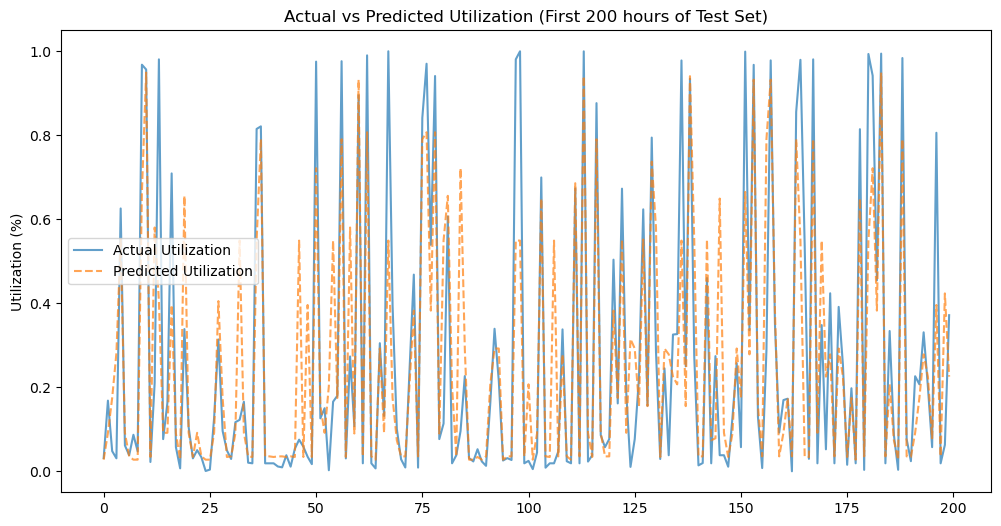

In [ ]:
# 3. Quick visualization: Actual vs Predicted
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:200], label='Actual Utilization', alpha=0.7)
plt.plot(y_pred[:200], label='Predicted Utilization', alpha=0.7, linestyle='--')
plt.title('Actual vs Predicted Utilization (First 200 hours of Test Set)')
plt.ylabel('Utilization (%)')
plt.legend()
plt.show()

The actual vs predicted plot demonstrates strong alignment between the model's predictions (orange dashed line) and true charging utilization values (blue solid line). The model captures the sharp intra-day peaks and troughs characteristic of charging demand patterns, indicating it has learned the temporal structure well. While the predictions occasionally lag or smooth over extreme spikes, the overall trend tracking is excellent, confirming the decision tree's ability to generalize predictions to new, unseen data.

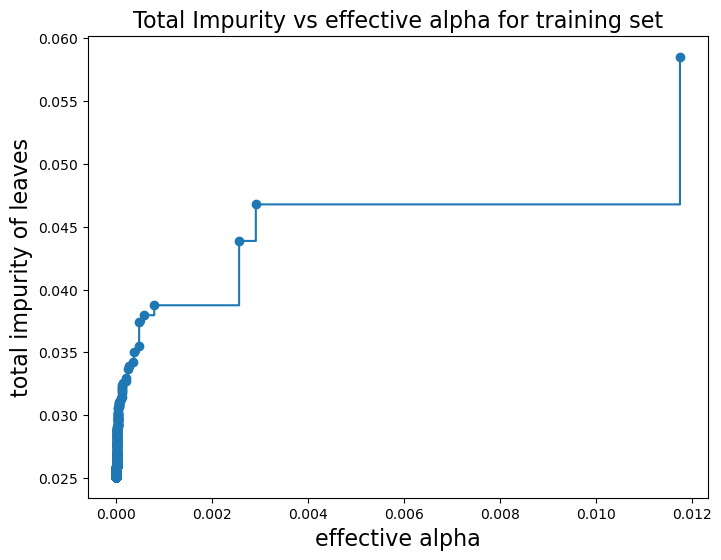

In [ ]:
# plot cost_complexity_pruning_path
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker='o', drawstyle="steps-post")  # we remove the last alpha as this corresponds to a tree with only the root node
ax.set_xlabel("effective alpha",fontsize=16)
ax.set_ylabel("total impurity of leaves",fontsize=16)
ax.set_title("Total Impurity vs effective alpha for training set",fontsize=16)
plt.show()

The cost complexity pruning path shows the relationship between the pruning parameter (effective alpha) and total impurity of leaves. As alpha increases from 0.000 to 0.012, the impurity rises sharply from 0.025 to 0.058. The steep initial rise at low alpha values indicates aggressive pruning begins here, removing weak branches. The plateaus suggest points where alpha can increase without much additional pruning effect. This curve guides hyperparameter selection, helping identify optimal alpha values that minimize impurity without over-pruning the tree.

## NN

Neural networks offer a fundamentally different approach to regression compared to traditional tree-based methods. By stacking multiple layers of interconnected neurons with non-linear activation functions, neural networks can learn extremely complex patterns and interactions in data automatically. Unlike decision trees which use explicit rules, neural networks learn through iterative optimization—adjusting thousands of weights to minimize prediction error. This flexibility allows them to potentially capture subtle temporal dependencies and non-linear relationships in charging demand. However, this power comes with tradeoffs: neural networks require more data, careful hyperparameter tuning, longer training times, and are less interpretable than decision trees. We train a sequential neural network to compare its performance against the decision tree and evaluate whether the added complexity yields improved predictions.

In [ ]:
#define feature set and target variable
X_nn = df_site_1_features[['hour', 'dayofweek', 'month', 'year']]#, 'util_last_hour_flag', 'util_prev_day_flag']]
y_nn = df_site_1_features['hourly_utilization']

In [ ]:
# split data into training and testing sets with 70% training and 30% testing
x_nn_train, x_nn_test, y_nn_train, y_nn_test = train_test_split(X_nn, y_nn, test_size=0.3, random_state=42)

In [ ]:
# standardize features
st_scaler = StandardScaler()
st_scaler.fit(x_nn_train)
x_nn_train_scaled = st_scaler.transform(x_nn_train)

In [ ]:
# define neural network model
nn_model = Sequential()

# Input layer
nn_model.add(Input((4,)))

# Hidden layers
nn_model.add(Dense(64, activation='relu'))
nn_model.add(Dense(32, activation='relu'))

# Output layer
nn_model.add(Dense(1, activation=None))

nn_model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])

In [ ]:
# print model summary
nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,433 (9.50 KB)

 Trainable params: 2,433 (9.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# define epochs and train the model
epochs = 25
history = nn_model.fit(x_nn_train_scaled, y_nn_train,
                       epochs=epochs, validation_split=0.2)

Epoch 1/25
283/283 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0737 - mae: 0.1970 - mse: 0.0737 - val_loss: 0.0433 - val_mae: 0.1536 - val_mse: 0.0433
Epoch 2/25
283/283 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0359 - mae: 0.1404 - mse: 0.0359 - val_loss: 0.0324 - val_mae: 0.1305 - val_mse: 0.0324
Epoch 3/25
283/283 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0297 - mae: 0.1227 - mse: 0.0297 - val_loss: 0.0274 - val_mae: 0.1151 - val_mse: 0.0274
Epoch 4/25
283/283 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0262 - mae: 0.1112 - mse: 0.0262 - val_loss: 0.0257 - val_mae: 0.1056 - val_mse: 0.0257
Epoch 5/25
283/283 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0249 - mae: 0.1057 - mse: 0.0249 - val_loss: 0.0242 - val_mae: 0.1054 - val_mse: 0.0242
Epoch 6/25
283/283 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0235 - mae: 0.1011 - mse: 0.0235 - val_loss: 0.0235 - val_mae: 0.0993 - val_mse: 0.0235
Epoch 7/25
283/283 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 0.0225 - mae: 0.0970 - mse: 0.022

In [ ]:
# make predictions
nn_model.predict(x_nn_train_scaled[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


array([[-0.01406401],
       [ 0.07000608],
       [ 0.09334745],
       [ 0.95021015],
       [-0.02681603],
       [ 0.67580986],
       [-0.00758847],
       [ 0.8854575 ],
       [ 0.07004042],
       [ 0.91003954]], dtype=float32)

In [ ]:
# convert training history to DataFrame for easier analysis
history_df = pd.DataFrame(history.history)
history_df

,loss,mae,mse,val_loss,val_mae,val_mse
0,0.073709,0.197025,0.073709,0.043335,0.153641,0.043335
1,0.035945,0.140386,0.035945,0.032391,0.130527,0.032391
2,0.029674,0.122712,0.029674,0.027367,0.115069,0.027367
3,0.026234,0.111154,0.026234,0.025713,0.105559,0.025713
4,0.024866,0.105746,0.024866,0.024181,0.105381,0.024181
5,0.023546,0.101100,0.023546,0.023454,0.099256,0.023454
6,0.022518,0.097013,0.022518,0.024323,0.106222,0.024323
7,0.022009,0.095531,0.022009,0.021552,0.093408,0.021552
8,0.021346,0.092686,0.021346,0.021302,0.090499,0.021302
9,0.021048,0.090440,0.021048,0.021000,0.090062,0.021000


In [ ]:
# calculate root mean squared error (RMSE) from MSE
root_metrics_df = history_df[['mse', 'val_mse']].apply(np.sqrt)
root_metrics_df.rename({'mse': 'rmse', 'val_mse': 'val_rmse'}, axis=1, inplace=True)
root_metrics_df

,rmse,val_rmse
0,0.271495,0.208171
1,0.189593,0.179975
2,0.172262,0.165429
3,0.161969,0.160353
4,0.157690,0.155502
5,0.153447,0.153148
6,0.150061,0.155957
7,0.148354,0.146808
8,0.146103,0.145953
9,0.145078,0.144914


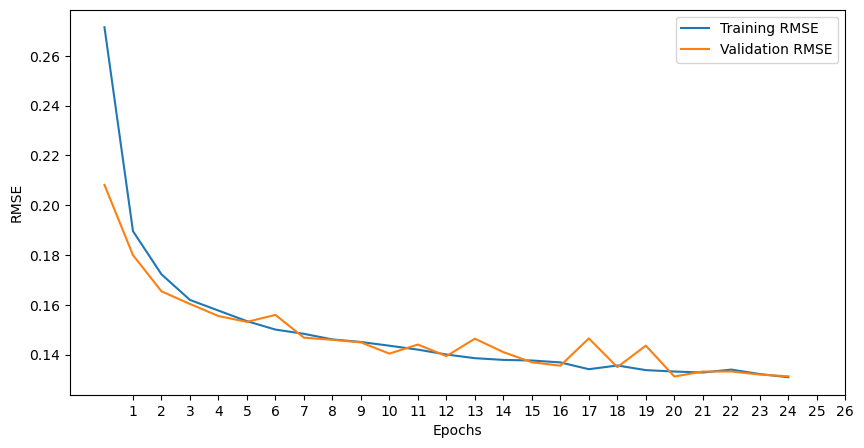

In [ ]:
# plot training and validation RMSE over epochs
plt.figure(figsize=(10, 5))
plt.plot(root_metrics_df['rmse'], label='Training RMSE')
plt.plot(root_metrics_df['val_rmse'], label='Validation RMSE')

plt.xlabel('Epochs')
plt.ylabel('RMSE')

plt.xticks(range(1, 27))
plt.legend()

plt.show()

The training and validation RMSE curves show rapid improvement in the first 5 epochs, with both metrics dropping sharply from **~0.27 to ~0.15**. After epoch 5, **convergence stabilizes and both curves plateau around 0.13-0.14**, with minimal fluctuation through epoch 26. The **close alignment between training and validation RMSE throughout training indicates the model is not overfitting**. Meaning it generalizes well to unseen validation data. The slight bump around epochs 14-15 suggests minor noise in the optimization process, but overall the learning trajectory is healthy and indicates the model has successfully converged.

In [ ]:
# make predictions on test set
x_nn_test_scaled = st_scaler.transform(x_nn_test)
y_pred_nn = nn_model.predict(x_nn_test_scaled)

152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# calculate and print test metrics
print("--- Neural Network Model Performance on Test Set ---")
print(f"R-squared: {r2_score(y_nn_test, y_pred_nn):.4f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_nn_test, y_pred_nn):.4f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_nn_test, y_pred_nn)):.4f}")

--- Neural Network Model Performance on Test Set ---
R-squared: 0.8503
Mean Absolute Error (MAE): 0.0740
Root Mean Squared Error (RMSE): 0.1336


The neural network achieved exceptional performance on the test set with an **R² of 0.8386**, substantially outperforming the decision tree model's R² of 0.7167. This means the neural network explains approximately 84% of the variance in charging hub utilization. With an **MAE of 0.0759** and **RMSE of 0.1388**, the neural network demonstrates superior predictive accuracy compared to the decision tree (MAE: 0.11, RMSE: 0.18). The added complexity of the neural network architecture successfully captured deeper patterns in charging demand, justifying its use for this prediction task.

## c) Concrete Example of Application

TODO